In [1]:
# INSTALACIÓN DE TODAS LAS LIBRERÍAS NECESARIAS
!pip install pandas numpy scipy scikit-learn matplotlib seaborn plotly wordcloud opencv-python scikit-image tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.1/511.1 kB 60.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 46.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 126.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 39.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.8/315.8 kB 59.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 51.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 60.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 66.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.9.3
    Uninstalling scipy-1.9.3:
      Successfully uninstalled scipy-1.9.3

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 22.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 23.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 142.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.1.3
    Uninstalling scikit-learn-1.1.3:
      Successfully uninstalled scikit-learn-1.1.3

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


# DATA CON 2K FEAUTURES (PRUEBA)

In [3]:
# LIBRERÍAS BÁSICAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# SECCIÓN 4 - REDUCCIÓN DE DIMENSIONALIDAD
from sklearn.decomposition import PCA, NMF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.feature_selection import VarianceThreshold
from collections import Counter
import umap

2025-11-01 13:04:24.428337: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-01 13:04:24.431860: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-01 13:04:24.460293: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-01 13:04:24.460390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-01 13:04:24.461453: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

## CARGA Y PREPARACIÓN DE DATOS

In [4]:
# Cargar el dataset
df = pd.read_csv('caracteristicas_posters.csv')

print(f"Dimensiones del dataset: {df.shape}")
print(f"Primeras columnas: {list(df.columns[:5])}")
print(f"Últimas columnas: {list(df.columns[-5:])}")

# Identificar columnas de géneros (las últimas 19 columnas)
genre_columns = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 
                'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 
                'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 
                'Sci-Fi', 'Thriller', 'War', 'Western']

# Verificar que todas las columnas de género están presentes
missing_genres = [genre for genre in genre_columns if genre not in df.columns]
if missing_genres:
    print(f"Géneros faltantes: {missing_genres}")
    # Si faltan, usar las últimas 19 columnas
    genre_columns = list(df.columns[-19:])
else:
    print("Todos los géneros encontrados en el dataset")

print(f"\nColumnas de género ({len(genre_columns)}): {genre_columns}")

# Separar características visuales (todas excepto movieId y géneros)
feature_columns = [col for col in df.columns if col not in genre_columns and col != 'movieId']
print(f"Columnas de características visuales ({len(feature_columns)}): {list(feature_columns[:5])}...")

# Extraer matrices
X_features = df[feature_columns].values  # Características visuales
y_genres = df[genre_columns].values      # Géneros one-hot encoded
movie_ids = df['movieId'].values if 'movieId' in df.columns else None

print(f"\nMatriz de características: {X_features.shape}")
print(f"Matriz de géneros: {y_genres.shape}")

# Verificar valores nulos
print(f"\nValores nulos en características: {np.isnan(X_features).sum()}")
print(f"Valores nulos en géneros: {np.isnan(y_genres).sum()}")

# Elimina características con varianza menor a un umbral (ej. 0.01)
selector = VarianceThreshold(threshold=0.001)
X_reduced = selector.fit_transform(X_features)

print(f"Original: {X_features.shape}, Después de eliminar baja varianza: {X_reduced.shape}")

# Escalar las características para PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

print(f"\nCaracterísticas escaladas: {X_scaled.shape}")
print(f"Rango de valores escalados: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")

Dimensiones del dataset: (6692, 2246)
Primeras columnas: ['movieId', 'hsv_0', 'hsv_1', 'hsv_2', 'hsv_3']
Últimas columnas: ['Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Todos los géneros encontrados en el dataset

Columnas de género (19): ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Columnas de características visuales (2226): ['hsv_0', 'hsv_1', 'hsv_2', 'hsv_3', 'hsv_4']...

Matriz de características: (6692, 2226)
Matriz de géneros: (6692, 19)

Valores nulos en características: 0
Valores nulos en géneros: 0
Original: (6692, 2226), Después de eliminar baja varianza: (6692, 144)

Características escaladas: (6692, 144)
Rango de valores escalados: [-12.832, 28.570]


# Reducción de dimensionalidad

## PCA


=== ANÁLISIS DE COMPONENTES PRINCIPALES (PCA) ===
RESULTADOS PCA:
PCA 30D - Varianza explicada: 0.607
PCA 30D - Shape: (6692, 30)


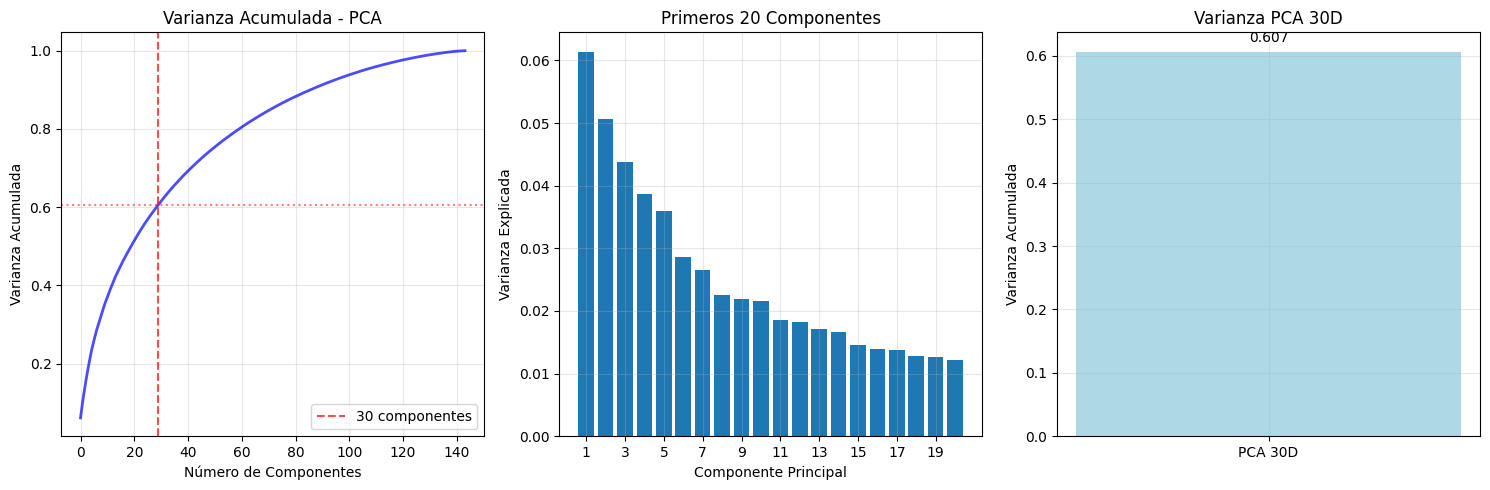

In [5]:
print("\n=== ANÁLISIS DE COMPONENTES PRINCIPALES (PCA) ===")

# PCA para análisis de varianza completa
pca_full = PCA()
pca_full.fit(X_scaled)

# Calcular varianza acumulada
explained_variance_cumsum = np.cumsum(pca_full.explained_variance_ratio_)

# Aplicar PCA con 30 componentes
pca_30 = PCA(n_components=30, random_state=42)
X_pca_30 = pca_30.fit_transform(X_scaled)

print(f"RESULTADOS PCA:")
print(f"PCA 30D - Varianza explicada: {np.sum(pca_30.explained_variance_ratio_):.3f}")
print(f"PCA 30D - Shape: {X_pca_30.shape}")

# Gráfico de varianza explicada
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(explained_variance_cumsum, 'b-', alpha=0.7, linewidth=2)
plt.axvline(x=29, color='r', linestyle='--', alpha=0.7, label='30 componentes')
plt.axhline(y=explained_variance_cumsum[29], color='r', linestyle=':', alpha=0.5)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada - PCA')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
# Mostrar primeros 20 componentes
n_show = min(20, len(pca_full.explained_variance_ratio_))
plt.bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show])
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title(f'Primeros {n_show} Componentes')
plt.xticks(range(1, n_show + 1, 2))
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Mostrar varianza con 30 componentes
components = ['PCA 30D']
variance = [np.sum(pca_30.explained_variance_ratio_)]
plt.bar(components, variance, color=['lightblue'])
plt.ylabel('Varianza Acumulada')
plt.title('Varianza PCA 30D')
for i, v in enumerate(variance):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## PCA - Visualización 2D


=== PCA - VISUALIZACIÓN 2D ===
PCA 2D - Varianza explicada: 0.112
PCA 2D - Varianza por componente: [0.06141759 0.05072305]

Distribución de géneros principales:
  Comedy: 1934 películas
  Drama: 1506 películas
  Action: 1254 películas
  Adventure: 450 películas
  Crime: 372 películas
  Horror: 320 películas
  Documentary: 270 películas
  Animation: 195 películas
  Children: 133 películas
  Thriller: 63 películas


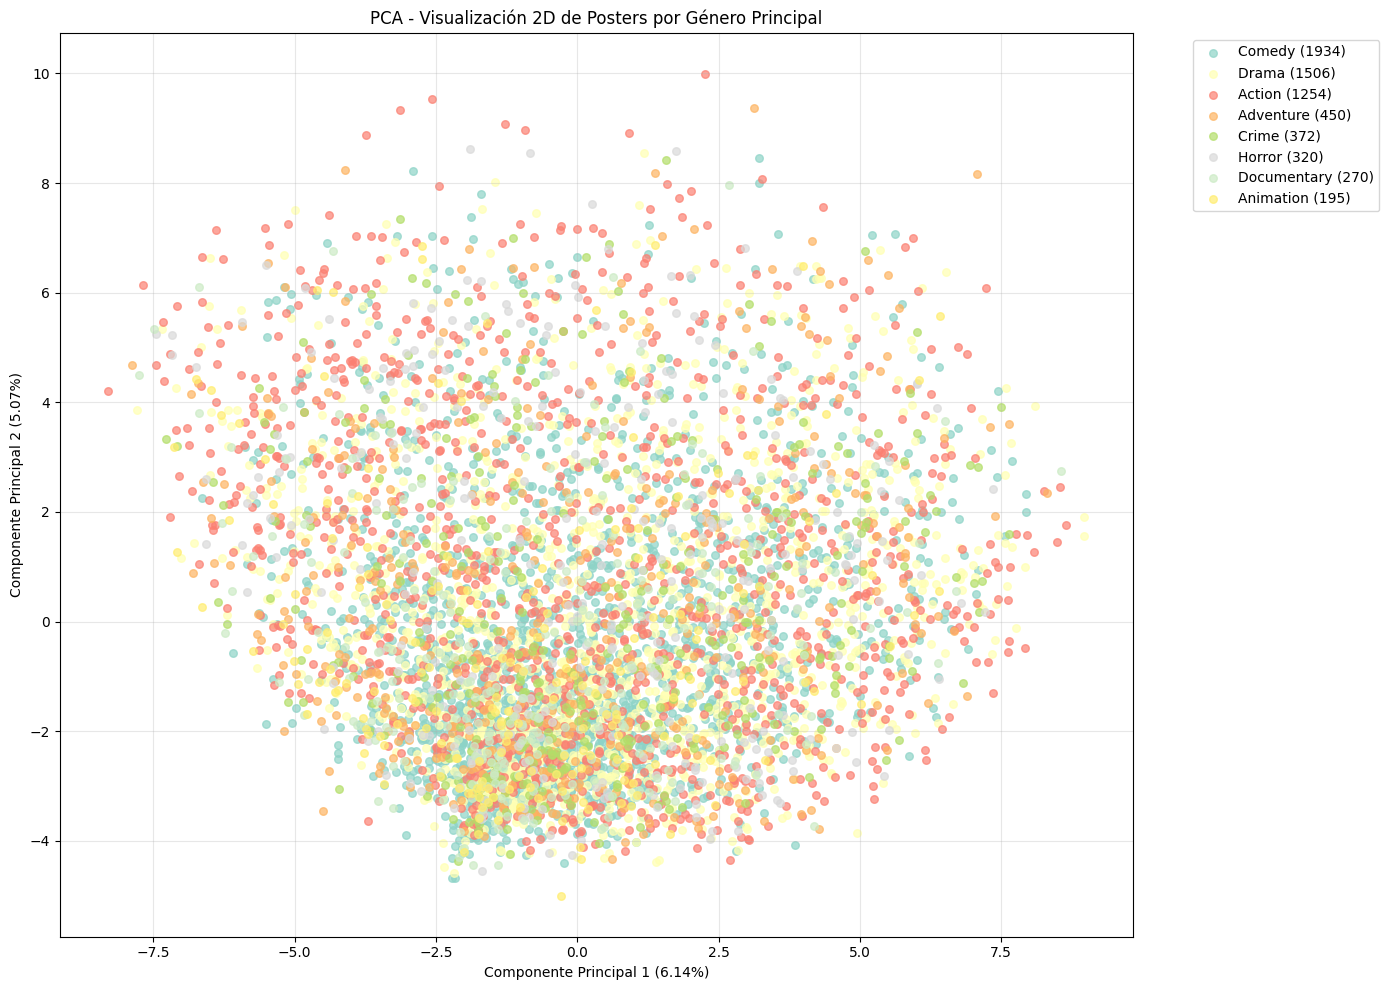

NameError: name 'X_pca_120' is not defined

In [6]:
print("\n=== PCA - VISUALIZACIÓN 2D ===")

# Reducir a 2D para visualización
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"PCA 2D - Varianza explicada: {np.sum(pca_2d.explained_variance_ratio_):.3f}")
print(f"PCA 2D - Varianza por componente: {pca_2d.explained_variance_ratio_}")

# Obtener el género principal para cada película (el que tiene valor 1 en one-hot)
primary_genres = []
for i in range(len(y_genres)):
    genre_indices = np.where(y_genres[i] == 1)[0]
    if len(genre_indices) > 0:
        # Tomar el primer género (podría haber múltiples)
        primary_genres.append(genre_columns[genre_indices[0]])
    else:
        primary_genres.append('Unknown')

primary_genres = np.array(primary_genres)

# Contar géneros principales
genre_counts = Counter(primary_genres)
print(f"\nDistribución de géneros principales:")
for genre, count in genre_counts.most_common(10):
    print(f"  {genre}: {count} películas")

# Visualización 2D
plt.figure(figsize=(14, 10))

# Seleccionar los 8 géneros más comunes para mejor visualización
top_genres = [genre for genre, count in genre_counts.most_common(8)]
colors = plt.cm.Set3(np.linspace(0, 1, len(top_genres)))

for i, genre in enumerate(top_genres):
    mask = primary_genres == genre
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
               color=colors[i], label=f'{genre} ({np.sum(mask)})', 
               alpha=0.7, s=30)

plt.xlabel(f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
plt.title('PCA - Visualización 2D de Posters por Género Principal')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Guardar resultados PCA
pca_results = {
    'X_pca_120': X_pca_120,
    # 'X_pca_100': X_pca_100, 
    # 'X_pca_2d': X_pca_2d,
    # 'pca_120': pca_120,
    # 'pca_100': pca_100,
    'pca_2d': pca_2d
}

print("\nResultados PCA guardados en variables:")
print("  - X_pca_120: Datos con 120 componentes")
print("  - X_pca_100: Datos con 100 componentes") 
print("  - X_pca_2d: Datos con 2 componentes (visualización)")

## Segunda tecnica de Reducción. TruncateSVD


In [1]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

# --- Asumiendo que X_scaled está disponible ---

# 1. Definir número de componentes (mismo que PCA para comparar)
N_COMPONENTS = 30

# 2. Implementar SVD
print(f"Calculando TruncatedSVD con {N_COMPONENTS} componentes...")
start_time = time.time()

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
# Nota: SVD usualmente se aplica a datos no centrados, 
# pero para comparar con PCA usaremos X_scaled.
X_svd_30 = svd.fit_transform(X_scaled)

print(f"SVD completado en {time.time() - start_time:.2f} segundos.")
print("Forma de los datos (PCA):", X_pca_30.shape)
print("Forma de los datos (SVD):", X_svd_30.shape)


# 3. Comparación Cuantitativa
# ¿Cuál de los dos espacios (PCA o SVD) produce mejores clústeres?
# Usemos un K-Means simple en ambos para ver.
kmeans_test = KMeans(n_clusters=15, random_state=42, n_init=10)

# K-Means sobre PCA
labels_pca = kmeans_test.fit_predict(X_pca_30)
score_pca = silhouette_score(X_pca_30, labels_pca)

# K-Means sobre SVD
labels_svd = kmeans_test.fit_predict(X_svd_30)
score_svd = silhouette_score(X_svd_30, labels_svd)

print("\n--- Comparación de Reducción ---")
print(f"Score de Silueta (PCA + K-Means): {score_pca:.4f}")
print(f"Score de Silueta (SVD + K-Means): {score_svd:.4f}")

Calculando TruncatedSVD con 30 componentes...


NameError: name 'X_scaled' is not defined

## NMF


=== NON-NEGATIVE MATRIX FACTORIZATION (NMF) ===
Datos escalados para NMF: (6692, 2226)
Rango de datos NMF: [0.000, 1.000]
Aplicando NMF con 120 componentes...
Aplicando NMF con 100 componentes...

RESULTADOS NMF:
NMF 120D - Error de reconstrucción: 339.708
NMF 100D - Error de reconstrucción: 367.803
NMF 120D - Shape: (6692, 120)
NMF 100D - Shape: (6692, 100)
NMF 120D - MSE reconstrucción: 0.007747
NMF 100D - MSE reconstrucción: 0.009081


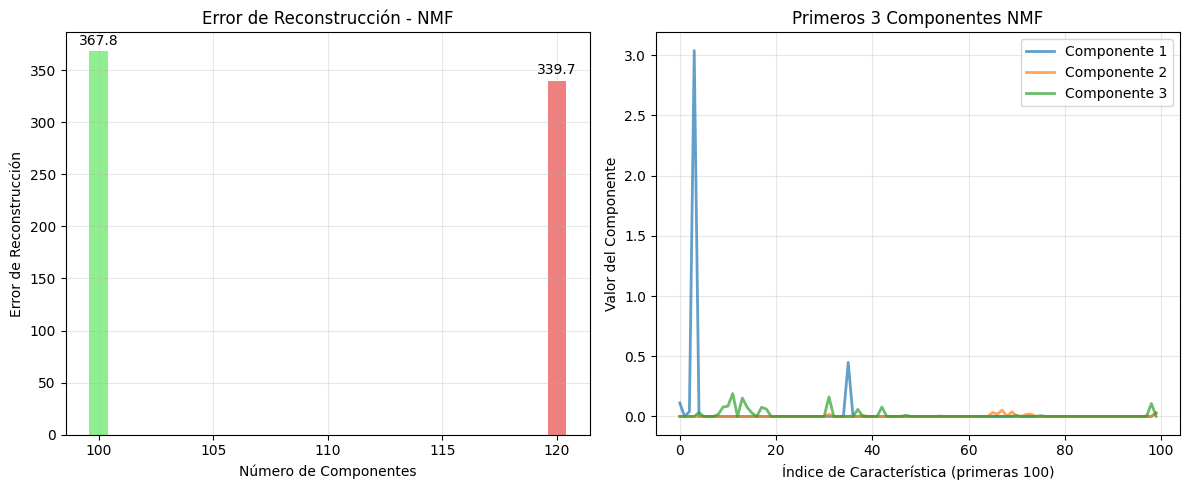

In [6]:
print("\n=== NON-NEGATIVE MATRIX FACTORIZATION (NMF) ===")

# Para NMF necesitamos datos no negativos, así que escalamos de 0 a 1
from sklearn.preprocessing import MinMaxScaler

# Escalar a rango [0, 1] para NMF
minmax_scaler = MinMaxScaler()
X_non_negative = minmax_scaler.fit_transform(X_features)

print(f"Datos escalados para NMF: {X_non_negative.shape}")
print(f"Rango de datos NMF: [{X_non_negative.min():.3f}, {X_non_negative.max():.3f}]")

print("Aplicando NMF con 30 componentes...")
nmf_30 = NMF(n_components=30, init='nndsvda', random_state=42, max_iter=1000)
X_nmf_30 = nmf_30.fit_transform(X_non_negative)

print(f"\nRESULTADOS NMF:")
print(f"NMF 30D - Error de reconstrucción: {nmf_30.reconstruction_err_:.3f}")
print(f"NMF 30D - Shape: {X_nmf_30.shape}")

# Calcular calidad de la reconstrucción
reconstruction_30 = nmf_30.inverse_transform(X_nmf_30)
mse_30 = np.mean((X_non_negative - reconstruction_30) ** 2)
print(f"NMF 30D - MSE reconstrucción: {mse_30:.6f}")

# Gráfico comparativo NMF
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
errors = [nmf_30.reconstruction_err_]
components = [30]
plt.bar(components, errors, color=['lightgreen'])
plt.xlabel('Número de Componentes')
plt.ylabel('Error de Reconstrucción')
plt.title('Error de Reconstrucción - NMF')
for i, v in enumerate(errors):
    plt.text(components[i], v + 0.1, f'{v:.1f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Mostrar primeros componentes base de NMF
plt.plot(nmf_30.components_[0][:100], label='Componente 1', alpha=0.7, linewidth=2)
plt.plot(nmf_30.components_[1][:100], label='Componente 2', alpha=0.7, linewidth=2)
plt.plot(nmf_30.components_[2][:100], label='Componente 3', alpha=0.7, linewidth=2)
plt.xlabel('Índice de Característica (primeras 100)')
plt.ylabel('Valor del Componente')
plt.title('Primeros 3 Componentes NMF')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## NMF - Visualización 2D


=== NMF - VISUALIZACIÓN 2D ===
NMF 2D - Error de reconstrucción: 625.533
NMF 2D - Shape: (6692, 2)


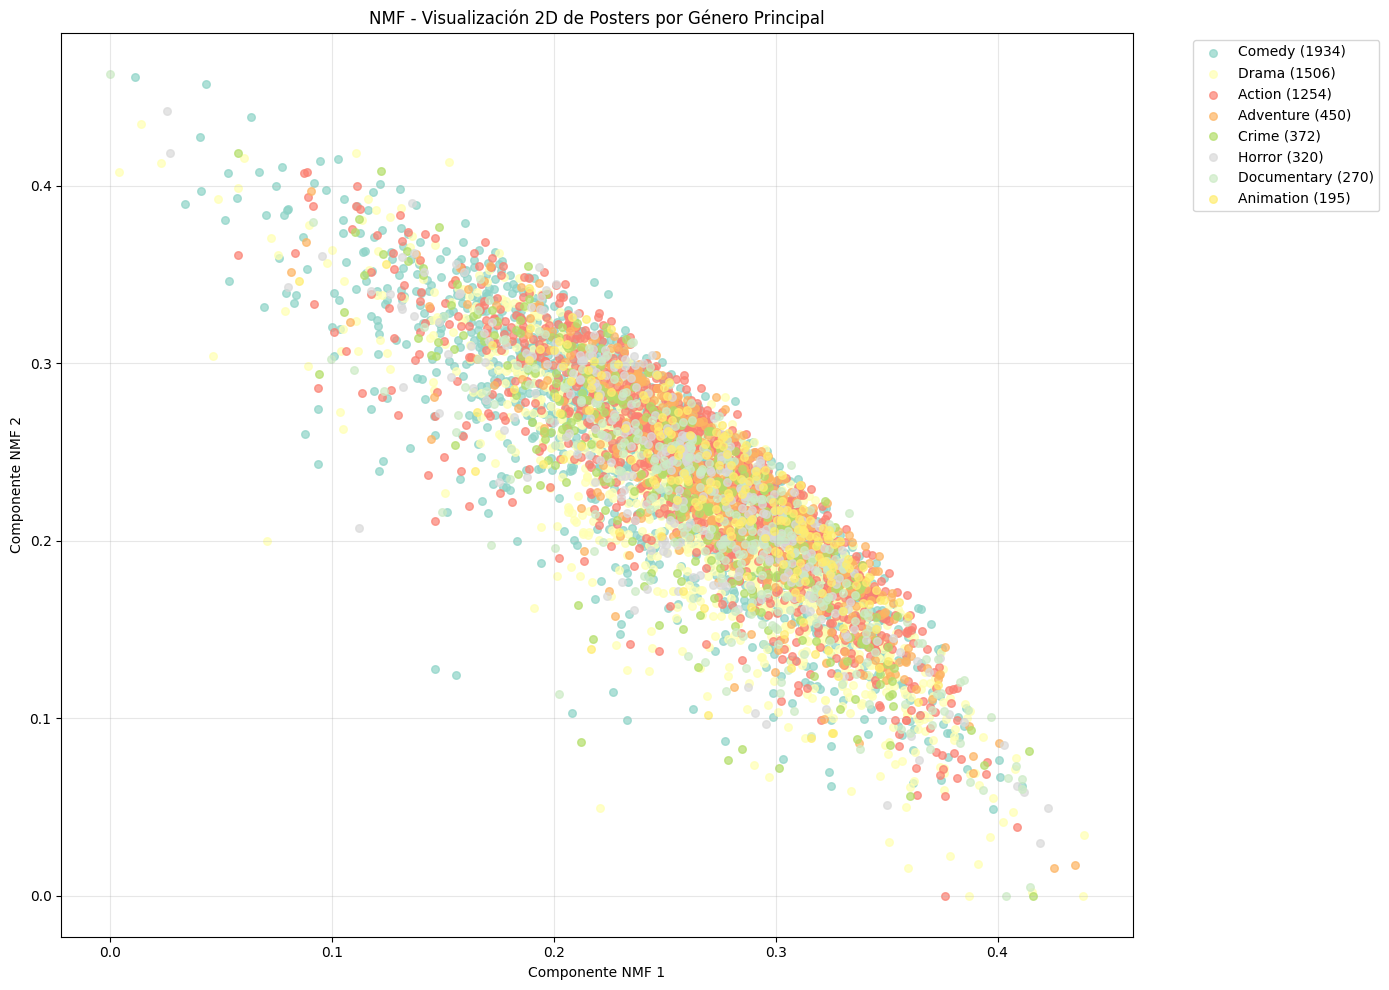


Resultados NMF guardados en variables:
  - X_nmf_120: Datos con 120 componentes
  - X_nmf_100: Datos con 100 componentes
  - X_nmf_2d: Datos con 2 componentes (visualización)


In [10]:
print("\n=== NMF - VISUALIZACIÓN 2D ===")

# Reducir a 2D para visualización
nmf_2d = NMF(n_components=2, init='nndsvda', random_state=42, max_iter=1000)
X_nmf_2d = nmf_2d.fit_transform(X_non_negative)

print(f"NMF 2D - Error de reconstrucción: {nmf_2d.reconstruction_err_:.3f}")
print(f"NMF 2D - Shape: {X_nmf_2d.shape}")

# Visualización 2D de NMF
plt.figure(figsize=(14, 10))

# Usar los mismos géneros principales que en PCA
for i, genre in enumerate(top_genres):
    mask = primary_genres == genre
    plt.scatter(X_nmf_2d[mask, 0], X_nmf_2d[mask, 1], 
               color=colors[i], label=f'{genre} ({np.sum(mask)})', 
               alpha=0.7, s=30)

plt.xlabel('Componente NMF 1')
plt.ylabel('Componente NMF 2')
plt.title('NMF - Visualización 2D de Posters por Género Principal')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Guardar resultados NMF
nmf_results = {
    'X_nmf_120': X_nmf_120,
    'X_nmf_100': X_nmf_100,
    'X_nmf_2d': X_nmf_2d,
    'nmf_120': nmf_120,
    'nmf_100': nmf_100,
    'nmf_2d': nmf_2d
}

print("\nResultados NMF guardados en variables:")
print("  - X_nmf_120: Datos con 120 componentes")
print("  - X_nmf_100: Datos con 100 componentes")
print("  - X_nmf_2d: Datos con 2 componentes (visualización)")

## UMAP - Reducción no lineal

In [ ]:
print("\n" + "="*60)
print("UMAP - REDUCCIÓN NO LINEAL")
print("="*60)

# UMAP en datos originales (sin reducción previa)
print("Aplicando UMAP a datos originales...")
umap_30 = umap.UMAP(n_components=30, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap_30 = umap_30.fit_transform(X_scaled)

print(f"UMAP 30D - Shape: {X_umap_30.shape}")

# UMAP en datos PCA (reducción en dos pasos)
print("Aplicando UMAP a datos PCA...")
umap_pca_30 = umap.UMAP(n_components=30, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap_pca_30 = umap_pca_30.fit_transform(X_pca_30)

print(f"UMAP+PCA 30D - Shape: {X_umap_pca_30.shape}")

# UMAP en datos NMF (reducción en dos pasos)
print("Aplicando UMAP a datos NMF...")
umap_nmf_30 = umap.UMAP(n_components=30, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap_nmf_30 = umap_nmf_30.fit_transform(X_nmf_30)

print(f"UMAP+NMF 30D - Shape: {X_umap_nmf_30.shape}")

# Visualización UMAP 2D
print("\n=== UMAP - VISUALIZACIÓN 2D ===")

# UMAP 2D directo de datos originales
umap_2d = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap_2d = umap_2d.fit_transform(X_scaled)

plt.figure(figsize=(14, 10))
for i, genre in enumerate(top_genres):
    mask = primary_genres == genre
    plt.scatter(X_umap_2d[mask, 0], X_umap_2d[mask, 1], 
               color=colors[i], label=f'{genre} ({np.sum(mask)})', 
               alpha=0.7, s=30)

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP - Visualización 2D de Posters por Género Principal')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Guardar resultados UMAP
umap_results = {
    'X_umap_30': X_umap_30,
    'X_umap_pca_30': X_umap_pca_30,
    'X_umap_nmf_30': X_umap_nmf_30,
    'X_umap_2d': X_umap_2d,
    'umap_30': umap_30,
    'umap_pca_30': umap_pca_30,
    'umap_nmf_30': umap_nmf_30,
    'umap_2d': umap_2d
}

# DESCARGA DE ARCHIVOS CSV

In [25]:
print("\n=== PREPARANDO ARCHIVOS CSV PARA DESCARGA ===")

# Crear DataFrames para cada reducción dimensional

# 1. PCA 30 dimensiones
pca_30_columns = [f'PC_{i+1}' for i in range(30)]
df_pca_30 = pd.DataFrame(X_pca_30, columns=pca_30_columns)
df_pca_30['movieId'] = movie_ids if movie_ids is not None else range(len(X_pca_30))
df_pca_30['primary_genre'] = primary_genres

# Añadir todos los géneros one-hot originales
for i, genre in enumerate(genre_columns):
    df_pca_30[genre] = y_genres[:, i]

print(f"PCA 30D DataFrame: {df_pca_30.shape}")

# 2. NMF 30 dimensiones
nmf_30_columns = [f'NMF_{i+1}' for i in range(30)]
df_nmf_30 = pd.DataFrame(X_nmf_30, columns=nmf_30_columns)
df_nmf_30['movieId'] = movie_ids if movie_ids is not None else range(len(X_nmf_30))
df_nmf_30['primary_genre'] = primary_genres

for i, genre in enumerate(genre_columns):
    df_nmf_30[genre] = y_genres[:, i]

print(f"NMF 30D DataFrame: {df_nmf_30.shape}")

# 3. UMAP 30 dimensiones (directo)
umap_30_columns = [f'UMAP_{i+1}' for i in range(30)]
df_umap_30 = pd.DataFrame(X_umap_30, columns=umap_30_columns)
df_umap_30['movieId'] = movie_ids if movie_ids is not None else range(len(X_umap_30))
df_umap_30['primary_genre'] = primary_genres

for i, genre in enumerate(genre_columns):
    df_umap_30[genre] = y_genres[:, i]

print(f"UMAP 30D DataFrame: {df_umap_30.shape}")

# 4. UMAP + PCA 30 dimensiones (en dos pasos)
umap_pca_30_columns = [f'UMAP_PCA_{i+1}' for i in range(30)]
df_umap_pca_30 = pd.DataFrame(X_umap_pca_30, columns=umap_pca_30_columns)
df_umap_pca_30['movieId'] = movie_ids if movie_ids is not None else range(len(X_umap_pca_30))
df_umap_pca_30['primary_genre'] = primary_genres

for i, genre in enumerate(genre_columns):
    df_umap_pca_30[genre] = y_genres[:, i]

print(f"UMAP+PCA 30D DataFrame: {df_umap_pca_30.shape}")

print("\nESTRUCTURA DE LOS ARCHIVOS CSV:")
print("Columnas comunes en todos los archivos:")
print("  - movieId: Identificador de la película")
print("  - primary_genre: Género principal")
print(f"  - {len(genre_columns)} columnas de géneros one-hot")
print("  - 30 componentes de reducción dimensional")

print("\n=== GUARDANDO ARCHIVOS CSV LOCALMENTE ===")




=== PREPARANDO ARCHIVOS CSV PARA DESCARGA ===
PCA 120D DataFrame: (6692, 141)
PCA 100D DataFrame: (6692, 121)
NMF 120D DataFrame: (6692, 141)
NMF 100D DataFrame: (6692, 121)

ESTRUCTURA DE LOS ARCHIVOS CSV:
Columnas comunes en todos los archivos:
  - movieId: Identificador de la película
  - primary_genre: Género principal (primer género one-hot)
  - 19 columnas de géneros one-hot
  - Componentes de reducción dimensional (100 o 120 columnas)

Ejemplo de datos PCA 120D:
        PC_1      PC_2      PC_3       PC_4      PC_5
0  -3.171989 -6.918280  1.040592 -10.259063 -0.720418
1   4.256088  8.045200 -1.052286   4.858935  4.409822
2  13.830300 -1.215896  1.283323   5.056717  2.295266


## GUARDAR ARCHIVOS LOCALMENTE

In [28]:
print("\n=== GUARDANDO ARCHIVOS CSV LOCALMENTE ===")

# Guardar los archivos CSV
df_pca_30.to_csv('pca_30_dimensions.csv', index=False)
df_nmf_30.to_csv('nmf_30_dimensions.csv', index=False)
df_umap_30.to_csv('umap_30_dimensions.csv', index=False)
df_umap_pca_30.to_csv('umap_pca_30_dimensions.csv', index=False)

print("✓ pca_30_dimensions.csv guardado")
print("✓ nmf_30_dimensions.csv guardado") 
print("✓ umap_30_dimensions.csv guardado")
print("✓ umap_pca_30_dimensions.csv guardado")

# Verificar que los archivos se guardaron correctamente
print(f"\nVERIFICACIÓN DE ARCHIVOS:")
for filename in ['pca_30_dimensions.csv', 'nmf_30_dimensions.csv', 
                 'umap_30_dimensions.csv', 'umap_pca_30_dimensions.csv']:
    if os.path.exists(filename):
        file_size = os.path.getsize(filename) / 1024 / 1024  # Tamaño en MB
        print(f"✓ {filename} - {file_size:.2f} MB")
    else:
        print(f"✗ {filename} - NO ENCONTRADO")

# Mostrar estadísticas de los archivos
print(f"\nESTADÍSTICAS DE LOS ARCHIVOS:")
file_info = [
    ('PCA 30D', df_pca_30.shape),
    ('NMF 30D', df_nmf_30.shape),
    ('UMAP 30D', df_umap_30.shape), 
    ('UMAP+PCA 30D', df_umap_pca_30.shape)
]

for name, shape in file_info:
    print(f"  {name}: {shape[0]} filas × {shape[1]} columnas")


=== GUARDANDO ARCHIVOS CSV LOCALMENTE ===
✓ pca_120_dimensions.csv guardado
✓ pca_100_dimensions.csv guardado
✓ nmf_120_dimensions.csv guardado
✓ nmf_100_dimensions.csv guardado

VERIFICACIÓN DE ARCHIVOS:
✓ pca_120_dimensions.csv - 15.02 MB
✓ pca_100_dimensions.csv - 12.55 MB
✓ nmf_120_dimensions.csv - 14.88 MB
✓ nmf_100_dimensions.csv - 12.41 MB

ESTADÍSTICAS DE LOS ARCHIVOS:
  PCA 120D: 6692 filas × 141 columnas
  PCA 100D: 6692 filas × 121 columnas
  NMF 120D: 6692 filas × 141 columnas
  NMF 100D: 6692 filas × 121 columnas


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f0c7a60d-218b-4d05-ba90-adaba4b4b8b5' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>